# Language Detection Using Recurrent Neural Networks

**Nizar Elouarti | AI 574 | Assignment 1**

Given a sentence, predict one of the ten Tatoeba language codes. This is multiclass sentence classification. Unlike a word-based sentiment model, this detector reads **characters**: spelling, accents, and character order provide useful language cues, including for unfamiliar words.

We use a character embedding followed by a bidirectional GRU (a gated recurrent neural network) and a linear classifier. The two final recurrent states summarize the sentence; cross-entropy trains the classifier on raw logits.

## Data and Experimental Design

The supplied training file actually has **100,000** sentences (10,000 per language); the development file has **10,000** (1,000 per language). To match the requested experiment, we select a seeded, stratified **10,000-sentence training subset**, and retain the complete development file for validation. Exact normalized train/validation duplicates are excluded from the training pool. Set `TRAIN_SIZE = None` to use the entire eligible training pool.

Character vocabulary and class mappings are fitted on training data only. Validation selects the best epoch; it is **not an independent test set**. Results below are measured by running the notebook, not assumed.

In [1]:
from pathlib import Path
import copy
import random
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset

SEED = 42
TRAIN_SIZE = 10_000
MAX_LENGTH = 160
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.003

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(min(4, torch.get_num_threads()))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

candidate_roots = [Path.cwd(), *Path.cwd().parents]
assignment_dir = next(
    (candidate for root in candidate_roots
     for candidate in (root, root / 'AI 574' / 'Assignment_1')
     if (candidate / 'Data' / 'tatoeba' / 'sentences.top10langs.train.tsv').is_file()),
    None,
)
if assignment_dir is None:
    raise FileNotFoundError('Run from the repository or assignment directory containing Data/tatoeba.')
data_dir = assignment_dir / 'Data' / 'tatoeba'


def normalize_text(text):
    return unicodedata.normalize('NFC', text).strip().lower()


def load_sentences(path):
    frame = pd.read_csv(path, sep='\t', header=None, names=['language', 'text'],
                        quoting=3, keep_default_na=False, encoding='utf-8')
    if frame.empty or not frame['language'].str.fullmatch(r'[a-z]{3}').all():
        raise ValueError(f'Invalid language codes in {path.name}')
    frame['text'] = frame['text'].map(normalize_text)
    if frame['text'].eq('').any():
        raise ValueError(f'Empty sentences in {path.name}')
    return frame


train_pool = load_sentences(data_dir / 'sentences.top10langs.train.tsv')
val_frame = load_sentences(data_dir / 'sentences.top10langs.dev.tsv')
original_train_count = len(train_pool)
train_pool = train_pool.loc[~train_pool['text'].isin(set(val_frame['text']))].copy()
removed_overlap = original_train_count - len(train_pool)
languages = sorted(train_pool['language'].unique())
assert len(languages) == 10
assert set(val_frame['language']) == set(languages)
if TRAIN_SIZE is None:
    train_frame = train_pool.reset_index(drop=True)
else:
    if TRAIN_SIZE <= 0 or TRAIN_SIZE % len(languages):
        raise ValueError('TRAIN_SIZE must be positive and divisible by the number of languages.')
    per_language = TRAIN_SIZE // len(languages)
    train_frame = pd.concat([
        train_pool.loc[train_pool['language'].eq(language)].sample(per_language, random_state=SEED)
        for language in languages
    ], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

language_names = {
    'ber': 'Berber', 'deu': 'German', 'eng': 'English', 'epo': 'Esperanto',
    'fra': 'French', 'hun': 'Hungarian', 'ita': 'Italian', 'por': 'Portuguese',
    'spa': 'Spanish', 'tur': 'Turkish',
}
label_to_id = {language: index for index, language in enumerate(languages)}
PAD_ID, UNK_ID = 0, 1
characters = sorted(set(''.join(train_frame['text'])))
char_to_id = {'<PAD>': PAD_ID, '<UNK>': UNK_ID}
char_to_id.update({character: index + 2 for index, character in enumerate(characters)})

print(f'Device: {device}; original training rows: {original_train_count:,}')
print(f'Train/validation overlap rows removed: {removed_overlap:,}')
print(f'Training: {len(train_frame):,}; validation: {len(val_frame):,}; vocabulary: {len(char_to_id)}')
print(f'Training sentences truncated at {MAX_LENGTH} characters: {(train_frame.text.str.len() > MAX_LENGTH).mean():.1%}')
display(pd.DataFrame({'train': train_frame.language.value_counts(),
                      'validation': val_frame.language.value_counts()}).sort_index())

Device: cpu; original training rows: 100,000
Train/validation overlap rows removed: 0
Training: 10,000; validation: 10,000; vocabulary: 125
Training sentences truncated at 160 characters: 0.4%


,train,validation
language,,
ber,1000,1000
deu,1000,1000
eng,1000,1000
epo,1000,1000
fra,1000,1000
hun,1000,1000
ita,1000,1000
por,1000,1000
spa,1000,1000


## Character Encoding and Recurrent Classifier

Normalize Unicode to NFC and lowercase while preserving accents and punctuation. Each character becomes a training-vocabulary ID; unseen characters use `<UNK>`. Sentences are truncated to 160 characters, padded within each batch, and **packed using their actual lengths** so padding never enters the recurrent state.

The network is `Embedding(32) -> bidirectional GRU(64) -> Dropout(0.2) -> Linear(10)`. It produces one score per language. No softmax is used before cross-entropy; softmax is used only to display prediction probabilities.

In [2]:
def encode_text(text, vocabulary=char_to_id, max_length=MAX_LENGTH):
    text = normalize_text(text)
    if not text:
        raise ValueError('Provide a non-empty sentence.')
    return torch.tensor([vocabulary.get(character, UNK_ID) for character in text[:max_length]],
                        dtype=torch.long)


class SentenceDataset(Dataset):
    def __init__(self, frame):
        self.sequences = [encode_text(text) for text in frame['text']]
        self.targets = [label_to_id[language] for language in frame['language']]

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]


def collate_sentences(batch):
    sequences, targets = zip(*batch)
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=PAD_ID)
    return padded, lengths, torch.tensor(targets, dtype=torch.long)


train_dataset = SentenceDataset(train_frame)
val_dataset = SentenceDataset(val_frame)
shuffle_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_sentences, generator=shuffle_generator, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate_sentences, num_workers=0)


class LanguageRNN(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=32, hidden_size=64, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_ID)
        self.rnn = nn.GRU(embedding_dim, hidden_size, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, character_ids, lengths):
        embedded = self.embedding(character_ids)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)
        sentence_state = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.classifier(self.dropout(sentence_state))


model_config = {'vocab_size': len(char_to_id), 'num_classes': len(languages),
                'embedding_dim': 32, 'hidden_size': 64, 'dropout': 0.2}
model = LanguageRNN(**model_config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

model.eval()
probe_sequence = encode_text('Hello world!')
probe_ids, probe_lengths, _ = collate_sentences([(probe_sequence, 0)])
with torch.no_grad():
    probe_logits = model(probe_ids.to(device), probe_lengths)
    extra_padding = torch.nn.functional.pad(probe_ids, (0, 9), value=PAD_ID)
    padded_logits = model(extra_padding.to(device), probe_lengths)
assert probe_logits.shape == (1, 10)
assert torch.isfinite(probe_logits).all()
assert torch.allclose(probe_logits, padded_logits, atol=1e-6)
assert encode_text(chr(0x1F642)).tolist() == [UNK_ID]
try:
    encode_text('   ')
except ValueError:
    pass
else:
    raise AssertionError('Empty text must be rejected.')
print(model)
print(f'Trainable parameters: {sum(parameter.numel() for parameter in model.parameters()):,}')
print('Smoke checks passed: output shape, finite logits, padding invariance, unknown and empty input.')

LanguageRNN(
  (embedding): Embedding(125, 32, padding_idx=0)
  (rnn): GRU(32, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)
Trainable parameters: 42,922
Smoke checks passed: output shape, finite logits, padding invariance, unknown and empty input.


## Training and Model Selection

Train with Adam and cross-entropy, clipping gradient norms to 1.0. Report sample-weighted loss and accuracy each epoch. Validation runs in evaluation mode with gradients disabled. Keep the weights with lowest validation loss and stop early after three epochs without improvement. The balanced random-guess accuracy baseline is **10%**.

In [4]:
import time


def run_epoch(loader, training=False):
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.set_grad_enabled(training):
        for character_ids, lengths, targets in loader:
            character_ids = character_ids.to(device)
            targets = targets.to(device)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(character_ids, lengths)
            loss = criterion(logits, targets)
            if not torch.isfinite(loss):
                raise RuntimeError('Non-finite training or validation loss.')
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_examples += targets.size(0)
            total_loss += loss.item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
    return total_loss / total_examples, total_correct / total_examples


history = []
best_val_loss = float('inf')
best_state = None
best_epoch = 0
patience = 3
stale_epochs = 0
for epoch in range(1, EPOCHS + 1):
    start_time = time.perf_counter()
    train_loss, train_accuracy = run_epoch(train_loader, training=True)
    val_loss, val_accuracy = run_epoch(val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
                    'train_accuracy': train_accuracy, 'val_accuracy': val_accuracy})
    print(f'Epoch {epoch:02d}: train loss {train_loss:.4f}, accuracy {train_accuracy:.2%} | '
          f'validation loss {val_loss:.4f}, accuracy {val_accuracy:.2%} | '
          f'{time.perf_counter() - start_time:.1f}s', flush=True)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= patience:
            print('Early stopping: validation loss stopped improving.')
            break

if best_state is None:
    raise RuntimeError('No trained model was selected.')
model.load_state_dict(best_state)
model.eval()
history_frame = pd.DataFrame(history)
print(f'Restored best model from epoch {best_epoch}.')

Epoch 01: train loss 0.0665, accuracy 97.93% | validation loss 0.1475, accuracy 95.25% | 32.1s
Epoch 02: train loss 0.0539, accuracy 98.37% | validation loss 0.1891, accuracy 93.77% | 22.3s
Epoch 03: train loss 0.0408, accuracy 98.79% | validation loss 0.1202, accuracy 96.25% | 23.3s
Epoch 04: train loss 0.0250, accuracy 99.37% | validation loss 0.1213, accuracy 96.33% | 28.6s
Epoch 05: train loss 0.0220, accuracy 99.36% | validation loss 0.1522, accuracy 95.62% | 24.4s
Epoch 06: train loss 0.0169, accuracy 99.62% | validation loss 0.1231, accuracy 96.22% | 27.2s
Early stopping: validation loss stopped improving.
Restored best model from epoch 3.


## Validation and Error Analysis

Evaluate the restored checkpoint on all 10,000 validation sentences. The report gives precision, recall, and F1 for each language; the row-normalized confusion matrix shows where sentences from each true language are assigned. Inspect misclassified examples rather than relying on overall accuracy alone.

In the current execution, the restored checkpoint has **96.25% validation accuracy**, **0.9625 macro F1**, and **0.1202 cross-entropy loss**. Portuguese recall is 91.0% and Spanish recall is 92.9%; their confusion is consistent with shared vocabulary and spelling. Training loss keeps decreasing while validation loss fluctuates, indicating overfitting. Epoch 3 is selected by lowest validation loss, although epoch 4 has slightly higher accuracy.

These are validation results, not independent test performance. The training cell was rerun without rerunning model initialization: its epoch numbers describe a continued training run, not training from scratch. For a fresh reproducible experiment, restart the kernel and run all cells in order; metrics will be recomputed and may differ.

Best epoch: 3; validation loss: 0.1202
Validation accuracy: 96.25%; macro F1: 0.9625
                  precision    recall  f1-score   support

    ber (Berber)      0.982     0.981     0.981      1000
    deu (German)      0.983     0.962     0.972      1000
   eng (English)      0.967     0.961     0.964      1000
 epo (Esperanto)      0.973     0.983     0.978      1000
    fra (French)      0.964     0.963     0.963      1000
 hun (Hungarian)      0.982     0.981     0.981      1000
   ita (Italian)      0.919     0.975     0.946      1000
por (Portuguese)      0.957     0.910     0.933      1000
   spa (Spanish)      0.919     0.929     0.924      1000
   tur (Turkish)      0.983     0.980     0.981      1000

        accuracy                          0.963     10000
       macro avg      0.963     0.963     0.963     10000
    weighted avg      0.963     0.963     0.963     10000



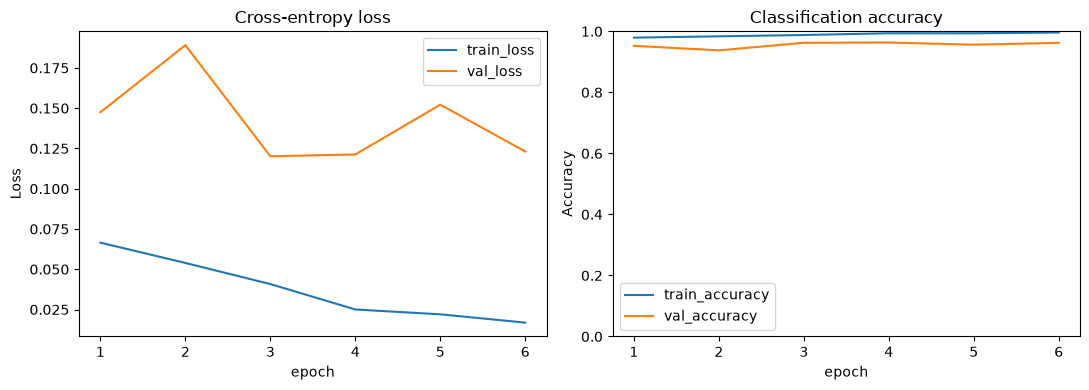

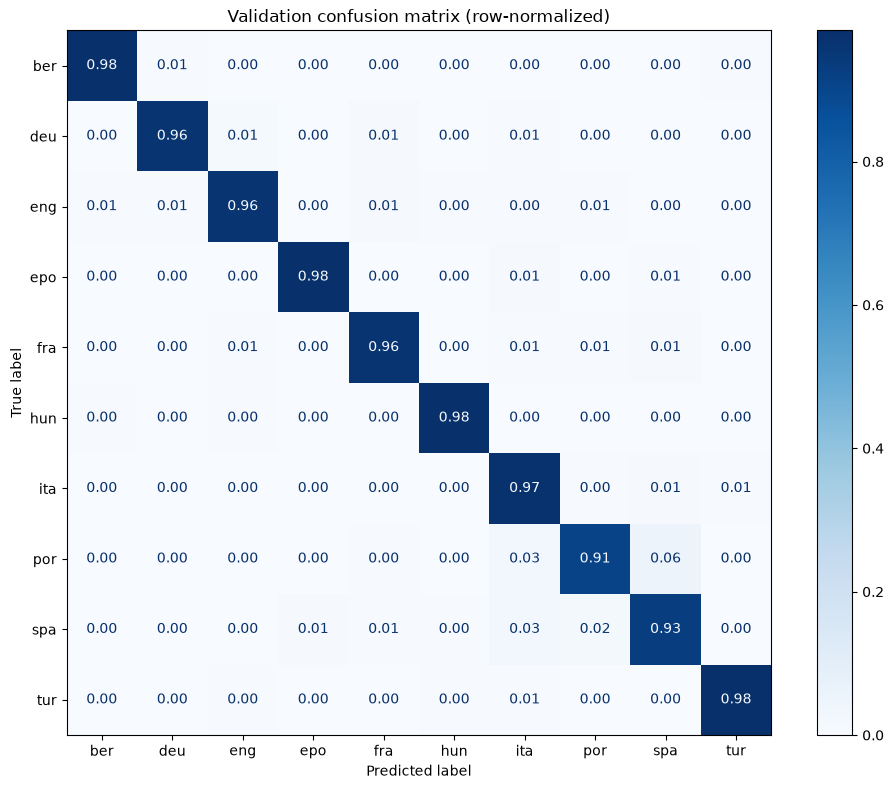

,language,text,predicted
1,por,"na semana que vem, tudo será diferente.",spa
2,por,tu deverias realmente beber menos café.,spa
13,por,abra as malas.,spa
19,por,a noite estava fria.,ita
27,por,"tentando passar de uma língua para outra, a ge...",spa
31,por,dirijo muito rápido.,spa
39,por,estás preparado para o pior?,spa
44,por,"sim, claro que concordo.",spa
55,por,esta cadeira de madeira custa sessenta libras.,spa
58,por,as eleições presidenciais foram influenciadas ...,spa


In [5]:
model.eval()
validation_targets = []
validation_predictions = []
validation_loss_sum = 0.0
with torch.inference_mode():
    for character_ids, lengths, targets in val_loader:
        logits = model(character_ids.to(device), lengths)
        validation_loss_sum += criterion(logits, targets.to(device)).item() * targets.size(0)
        validation_targets.extend(targets.tolist())
        validation_predictions.extend(logits.argmax(dim=1).cpu().tolist())

validation_accuracy = np.mean(np.array(validation_targets) == np.array(validation_predictions))
validation_loss = validation_loss_sum / len(validation_targets)
validation_macro_f1 = f1_score(validation_targets, validation_predictions, average='macro')
assert np.isclose(validation_loss, best_val_loss, atol=1e-6)
print(f'Best epoch: {best_epoch}; validation loss: {validation_loss:.4f}')
print(f'Validation accuracy: {validation_accuracy:.2%}; macro F1: {validation_macro_f1:.4f}')
print(classification_report(
    validation_targets, validation_predictions, labels=list(range(len(languages))),
    target_names=[f'{code} ({language_names.get(code, code)})' for code in languages],
    digits=3, zero_division=0,
))

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
history_frame.plot(x='epoch', y=['train_loss', 'val_loss'], ax=axes[0])
axes[0].set(title='Cross-entropy loss', ylabel='Loss')
history_frame.plot(x='epoch', y=['train_accuracy', 'val_accuracy'], ax=axes[1])
axes[1].set(title='Classification accuracy', ylabel='Accuracy', ylim=(0, 1))
figure.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(
    validation_targets, validation_predictions, labels=list(range(len(languages))),
    display_labels=languages, normalize='true', cmap='Blues', values_format='.2f',
    ax=plt.subplots(figsize=(10, 8))[1],
 )
plt.title('Validation confusion matrix (row-normalized)')
plt.tight_layout()
plt.show()

error_mask = np.array(validation_targets) != np.array(validation_predictions)
errors = val_frame.loc[error_mask, ['language', 'text']].copy()
errors['predicted'] = [languages[index] for index in np.array(validation_predictions)[error_mask]]
display(errors.head(10))

## Detect a Language and Save the Model

Call `predict_language('Bonjour, comment allez-vous ?')` to return the three highest-ranked language codes, names, and softmax probabilities. Set `top_k=1` for a single prediction. Empty text is rejected. Input uses the same normalization, vocabulary, and truncation as training.

This is a closed-set detector: it always chooses among the ten trained languages, even for unsupported languages or mixed-language text. Very short sentences may be ambiguous, and softmax probabilities are not calibrated guarantees of correctness.

Save the selected weights together with the character vocabulary, language ordering, architecture, and preprocessing configuration. The reload check reconstructs the network on CPU and verifies matching rankings and probabilities. For inference with the reloaded network, pass `predictor=loaded_model`, `vocabulary=checkpoint['char_to_id']`, `language_codes=checkpoint['languages']`, and `max_length=checkpoint['max_length']` to `predict_language`.

In [6]:
def predict_language(text, top_k=3, predictor=None, vocabulary=None,
                     language_codes=None, max_length=None):
    if predictor is None:
        predictor = model
    if vocabulary is None:
        vocabulary = char_to_id
    if language_codes is None:
        language_codes = languages
    if max_length is None:
        max_length = MAX_LENGTH
    if not isinstance(top_k, int) or not 1 <= top_k <= len(language_codes):
        raise ValueError('top_k must be between 1 and the number of supported languages.')
    sequence = encode_text(text, vocabulary=vocabulary, max_length=max_length)
    character_ids = sequence.unsqueeze(0).to(next(predictor.parameters()).device)
    lengths = torch.tensor([len(sequence)], dtype=torch.long)
    predictor.eval()
    with torch.inference_mode():
        probabilities = predictor(character_ids, lengths).softmax(dim=1)[0].cpu()
    scores, indices = probabilities.topk(top_k)
    return pd.DataFrame({
        'code': [language_codes[index] for index in indices.tolist()],
        'language': [language_names.get(language_codes[index], language_codes[index])
                     for index in indices.tolist()],
        'probability': scores.tolist(),
    })

example_sentences = {
    'eng': 'This morning I went to the library to read a book.',
    'fra': 'Bonjour, je voudrais un billet pour Paris.',
    'deu': 'Ich lese jeden Morgen die Zeitung.',
    'spa': 'Buenos dias, quiero comprar un libro.',
}
for expected_code, sentence in example_sentences.items():
    print(f'Input ({expected_code}): {sentence}')
    display(predict_language(sentence))

checkpoint_path = assignment_dir / 'language_rnn.pt'
torch.save({
    'model_state_dict': {name: value.detach().cpu() for name, value in model.state_dict().items()},
    'model_config': model_config,
    'char_to_id': char_to_id,
    'languages': languages,
    'max_length': MAX_LENGTH,
    'normalization': 'NFC, strip, lowercase',
    'seed': SEED,
    'train_size': len(train_frame),
    'best_epoch': best_epoch,
    'validation_accuracy': float(validation_accuracy),
    'validation_macro_f1': float(validation_macro_f1),
}, checkpoint_path)

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
loaded_model = LanguageRNN(**checkpoint['model_config'])
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

for sentence in example_sentences.values():
    original = predict_language(sentence, top_k=len(languages))
    restored = predict_language(
        sentence, top_k=len(checkpoint['languages']), predictor=loaded_model,
        vocabulary=checkpoint['char_to_id'], language_codes=checkpoint['languages'],
        max_length=checkpoint['max_length'],
    )
    assert original['code'].tolist() == restored['code'].tolist()
    assert np.allclose(original['probability'], restored['probability'], atol=1e-6)
try:
    predict_language('   ')
except ValueError:
    pass
else:
    raise AssertionError('Empty prediction input must be rejected.')
print(f'Saved checkpoint: {checkpoint_path}')
print('Reload checks passed: rankings and probabilities match; empty input is rejected.')

Input (eng): This morning I went to the library to read a book.


,code,language,probability
0,eng,English,0.999987
1,deu,German,0.000008
2,fra,French,0.000004


Input (fra): Bonjour, je voudrais un billet pour Paris.


,code,language,probability
0,fra,French,0.999808
1,eng,English,0.000165
2,por,Portuguese,0.000012


Input (deu): Ich lese jeden Morgen die Zeitung.


,code,language,probability
0,deu,German,0.999771
1,fra,French,0.000121
2,eng,English,0.000088


Input (spa): Buenos dias, quiero comprar un libro.


,code,language,probability
0,spa,Spanish,0.999463
1,epo,Esperanto,0.000321
2,por,Portuguese,0.000143


Saved checkpoint: c:\Github\dl-ai570\AI 574\Assignment_1\language_rnn.pt
Reload checks passed: rankings and probabilities match; empty input is rejected.
